In [18]:
import os 
print(os.getcwd())

c:\Users\Utilisateur\Desktop\rush03\algorithmes


In [ ]:
from pathlib import Path
import pandas as pd

# ici on configue les chemin pour obtenir les données
train_path = "../data/train.csv"
test_path = "../data/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df.head()


,index,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [28]:
#créér un rapport des valeurs manquantes
def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    missing = df.isna().sum()
    pct = (missing / len(df)) * 100
    report = pd.DataFrame({"missing": missing, "missing_pct": pct})
    report = report[report["missing"] > 0].sort_values("missing", ascending=False)
    return report
#Pour les données d'entrainement et de test
missing_train = missing_report(train_df)
missing_test = missing_report(test_df)

missing_train


,missing,missing_pct
Arrival Delay in Minutes,310,0.298352


In [ ]:
from sklearn.impute import SimpleImputer

#enlever une colonne d'index éventuelle
for df in (train_df, test_df):
    df.drop(columns=["index", "Unnamed: 0"], errors="ignore", inplace=True)

# Séparer cible pour le filtrage
target_col = "satisfaction"

# Colonnes catégorielles
categorical_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]
#colonnes numériques
numeric_cols = [
    c for c in train_df.columns
    if c not in categorical_cols + [target_col]
]

# Imputation uniquement pour les numériques comme on a des valeurs manquantes uniquement pour les numériques
num_imputer = SimpleImputer(strategy="median")

train_num = pd.DataFrame(
    num_imputer.fit_transform(train_df[numeric_cols]),
    columns=numeric_cols,
    index=train_df.index,
)
test_num = pd.DataFrame(
    num_imputer.transform(test_df[numeric_cols]),
    columns=numeric_cols,
    index=test_df.index,
)

# copier les colonnes catégorielles pour la concaténation
train_cat = train_df[categorical_cols].copy()
test_cat = test_df[categorical_cols].copy()

# Recomposer les dataframes imputés
train_imputed = pd.concat([train_num, train_cat, train_df[[target_col]]], axis=1)
test_imputed = pd.concat([test_num, test_cat, test_df[[target_col]]], axis=1)

train_imputed.isna().sum().sort_values(ascending=False).head()


id                                   0
Age                                  0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
dtype: int64

In [ ]:
# Feature engineering préliminaire
service_cols = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness",
]

for df in (train_imputed, test_imputed):
    #Le retard total est la somme des retards de départ et d'arrivée
    df["TotalDelay"] = df["Departure Delay in Minutes"] + df["Arrival Delay in Minutes"]
    #La satisfaction moyenne des services est la moyenne des notes des services
    df["ServiceSatisfactionMean"] = df[service_cols].mean(axis=1)

train_imputed.head()


,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction,TotalDelay,ServiceSatisfactionMean
0,70172.0,13.0,460.0,3.0,4.0,3.0,1.0,5.0,3.0,5.0,...,5.0,25.0,18.0,Male,Loyal Customer,Personal Travel,Eco Plus,neutral or dissatisfied,43.0,3.857143
1,5047.0,25.0,235.0,3.0,2.0,3.0,3.0,1.0,3.0,1.0,...,1.0,1.0,6.0,Male,disloyal Customer,Business travel,Business,neutral or dissatisfied,7.0,2.285714
2,110028.0,26.0,1142.0,2.0,2.0,2.0,2.0,5.0,5.0,5.0,...,5.0,0.0,0.0,Female,Loyal Customer,Business travel,Business,satisfied,0.0,3.714286
3,24026.0,25.0,562.0,2.0,5.0,5.0,5.0,2.0,2.0,2.0,...,2.0,11.0,9.0,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied,20.0,3.000000
4,119299.0,61.0,214.0,3.0,3.0,3.0,3.0,4.0,5.0,5.0,...,3.0,0.0,0.0,Male,Loyal Customer,Business travel,Business,satisfied,0.0,3.500000


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Préparer X/y
X_train = train_imputed.drop(columns=[target_col])
y_train = train_imputed[target_col]
X_test = test_imputed.drop(columns=[target_col])

# Redéfinir les colonnes numériques après features(TotalDelay, ServiceSatisfactionMean) ajoutées
categorical_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(), categorical_cols),
    ],
    remainder="drop",
)

X_train_prepared = preprocess.fit_transform(X_train)
X_test_prepared = preprocess.transform(X_test)

X_train_prepared.shape, X_test_prepared.shape


((103904, 30), (25976, 30))

In [17]:
X_train_prepared


array([[ 0.1400769 , -1.7452793 , -0.73153876, ...,  0.        ,
         0.        ,  1.        ],
       [-1.59827564, -0.95136024, -0.95718354, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.20393531, -0.88520032, -0.04758435, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 0.10412203, -0.62056063,  0.8078601 , ...,  1.        ,
         0.        ,  0.        ],
       [-0.28697726, -1.14984   , -0.18999128, ...,  0.        ,
         1.        ,  0.        ],
       [-0.06291997, -0.8190404 ,  0.53508063, ...,  1.        ,
         0.        ,  0.        ]], shape=(103904, 30))

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline

# Entraînement sur train.csv, évaluation sur test.csv
X_train = train_imputed.drop(columns=[target_col])
y_train = train_imputed[target_col]
X_test = test_imputed.drop(columns=[target_col])
y_test = test_imputed[target_col]

# Fonction d'évaluation
def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    return {
        "accuracy": accuracy_score(y_te, preds),
        "precision": precision_score(y_te, preds, pos_label="satisfied"),
        "recall": recall_score(y_te, preds, pos_label="satisfied"),
        "f1": f1_score(y_te, preds, pos_label="satisfied"),
    }

(y_train.value_counts(normalize=True) * 100).round(2), (y_test.value_counts(normalize=True) * 100).round(2)


(satisfaction
 neutral or dissatisfied    56.67
 satisfied                  43.33
 Name: proportion, dtype: float64,
 satisfaction
 neutral or dissatisfied    56.1
 satisfied                  43.9
 Name: proportion, dtype: float64)

In [21]:
from sklearn.linear_model import LogisticRegression

log_reg = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)

log_reg_metrics = evaluate_model(log_reg, X_train, y_train, X_test, y_test)
log_reg_metrics


{'accuracy': 0.8720357252848784,
 'precision': np.float64(0.8685338928929842),
 'recall': np.float64(0.8348680171884592),
 'f1': np.float64(0.851368270434627)}

In [23]:
# Feature importance (coefficients) pour la régression logistique
# On récupère les noms après le prétraitement
feature_names = log_reg.named_steps["preprocess"].get_feature_names_out()
coeffs = log_reg.named_steps["model"].coef_.ravel()

importance_df = pd.DataFrame(
    {"feature": feature_names, "coefficient": coeffs, "abs_coeff": abs(coeffs)}
).sort_values("abs_coeff", ascending=False)

importance_df.head(20)


,feature,coefficient,abs_coeff
26,cat__Type of Travel_Personal Travel,-1.671792,1.671792
24,cat__Customer Type_disloyal Customer,-1.326352,1.326352
25,cat__Type of Travel_Business travel,1.033299,1.033299
8,num__Online boarding,0.789075,0.789075
23,cat__Customer Type_Loyal Customer,0.687859,0.687859
29,cat__Class_Eco Plus,-0.550660,0.550660
3,num__Inflight wifi service,0.474295,0.474295
28,cat__Class_Eco,-0.425014,0.425014
14,num__Checkin service,0.374110,0.374110
11,num__On-board service,0.347999,0.347999


In [22]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [3, 5, 7, 9, 11]
results = []

for k in k_values:
    knn = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", KNeighborsClassifier(n_neighbors=k)),
        ]
    )
    metrics = evaluate_model(knn, X_train, y_train, X_test, y_test)
    metrics["k"] = k
    results.append(metrics)

pd.DataFrame(results).sort_values("f1", ascending=False)


,accuracy,precision,recall,f1,k
2,0.930821,0.946791,0.892572,0.918882,7
3,0.930089,0.947280,0.890292,0.917902,9
4,0.929435,0.948034,0.887924,0.916995,11
1,0.928973,0.942992,0.892134,0.916858,5
0,0.925239,0.934989,0.891695,0.912829,3


In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

# Comparaison des métriques
comparison = pd.DataFrame(
    [{"model": "LogisticRegression", **log_reg_metrics}]
    + [
        {"model": f"KNN(k={r['k']})", **{k: v for k, v in r.items() if k != "k"}}
        for r in results
    ]
).sort_values("f1", ascending=False)

comparison


,model,accuracy,precision,recall,f1
3,KNN(k=7),0.930821,0.946791,0.892572,0.918882
4,KNN(k=9),0.930089,0.947280,0.890292,0.917902
5,KNN(k=11),0.929435,0.948034,0.887924,0.916995
2,KNN(k=5),0.928973,0.942992,0.892134,0.916858
1,KNN(k=3),0.925239,0.934989,0.891695,0.912829
0,LogisticRegression,0.872036,0.868534,0.834868,0.851368


In [25]:
# Sélection du meilleur modèle (selon F1)
best_knn = max(results, key=lambda r: r["f1"])

if log_reg_metrics["f1"] >= best_knn["f1"]:
    best_model = log_reg
    best_model_name = "LogisticRegression"
else:
    best_k = best_knn["k"]
    best_model = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", KNeighborsClassifier(n_neighbors=best_k)),
        ]
    )
    best_model_name = f"KNN(k={best_k})"

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

best_model_name


'KNN(k=7)'

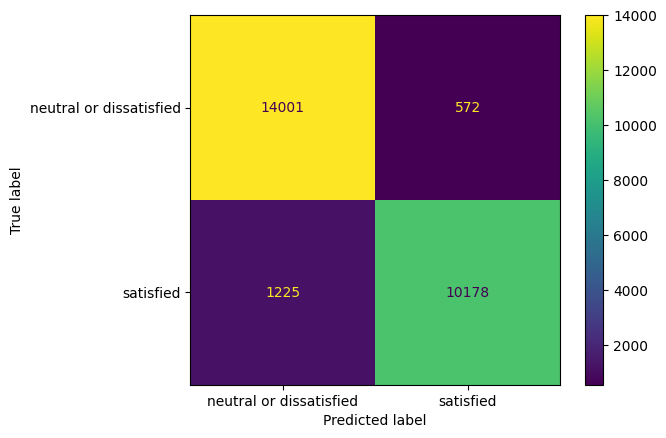

In [27]:
# Confusion matrix (valeurs entières)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["neutral or dissatisfied", "satisfied"],
    values_format="d",
)
